In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import normaltest


In [229]:
# Load the wine datasets
red_wine_df = pd.read_excel('WineData/winequality-red.xlsx', header=1)
white_wine_df = pd.read_excel('WineData/winequality-white.xlsx', header=1)

# Display the first few rows of each dataframe
red_wine_df.head()
white_wine_df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [230]:
def clean_data(df):
    # Make a copy of the dataframe to avoid modifying the original
    df = df.copy()

    # Ensure that column names are all strings before stripping any spaces
    df.columns = df.columns.astype(str).str.strip()

    # Drop any rows with missing values
    df = df.dropna()

    # Ensure that the numeric columns are of the correct type
    numeric_columns = df.columns[df.columns != 'quality']
    df.loc[:, numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

    # Drop any rows with NaN values after type conversion
    df = df.dropna()

    # Remove duplicate rows
    df = df.drop_duplicates()

    return df

In [231]:

# Clean both the red and white wine datasets
red_wine_df_cleaned = clean_data(red_wine_df)
white_wine_df_cleaned = clean_data(white_wine_df)

# Display both tables properly
print("Red Wine Data (Cleaned):")
display(red_wine_df_cleaned.head())

print("\nWhite Wine Data (Cleaned):")
display(white_wine_df_cleaned.head())

Red Wine Data (Cleaned):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5



White Wine Data (Cleaned):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


In [232]:
# Red Wine Data - Adding 'wine_type' column before merging
red_wine_df['wine_type'] = 'red'

# White Wine Data - Adding 'wine_type' column before merging
white_wine_df['wine_type'] = 'white'

# Merge the two datasets (keeping all rows from both)
combined_wine_df = pd.concat([red_wine_df, white_wine_df], ignore_index=True)

# Now, let's check the first few rows of the combined data
combined_wine_df.head(3000)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,7.3,0.18,0.29,1.2,0.044,12.0,143.0,0.9918,3.20,0.48,11.3,7,white
2996,7.3,0.25,0.36,13.1,0.050,35.0,200.0,0.9986,3.04,0.46,8.9,7,white
2997,7.3,0.25,0.36,13.1,0.050,35.0,200.0,0.9986,3.04,0.46,8.9,7,white
2998,7.0,0.20,0.34,5.7,0.035,32.0,83.0,0.9928,3.19,0.46,11.5,6,white


In [233]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to the 'wine_type' column
label_encoder = LabelEncoder()
combined_wine_df['wine_type_encoded'] = label_encoder.fit_transform(combined_wine_df['wine_type'])

# Display the first few rows of the transformed dataset
combined_wine_df.head(3000)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,wine_type_encoded
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,7.3,0.18,0.29,1.2,0.044,12.0,143.0,0.9918,3.20,0.48,11.3,7,white,1
2996,7.3,0.25,0.36,13.1,0.050,35.0,200.0,0.9986,3.04,0.46,8.9,7,white,1
2997,7.3,0.25,0.36,13.1,0.050,35.0,200.0,0.9986,3.04,0.46,8.9,7,white,1
2998,7.0,0.20,0.34,5.7,0.035,32.0,83.0,0.9928,3.19,0.46,11.5,6,white,1


In [234]:
from scipy.stats import normaltest

# Descriptive statistics
print("Descriptive Statistics:\n")
display(combined_wine_df.describe())

# Normality testing
print("\nNormality Test Results (D’Agostino and Pearson):\n")
numeric_columns = combined_wine_df.select_dtypes(include=[np.number]).columns
for column in numeric_columns:
    stat, p = normaltest(combined_wine_df[column])
    result = "Not normal" if p < 0.05 else "Normal"
    print(f"{column}: stat={stat:.3f}, p={p:.3g} → {result}")


Descriptive Statistics:



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type_encoded
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000



Normality Test Results (D’Agostino and Pearson):

fixed acidity: stat=2337.630, p=0 → Not normal
volatile acidity: stat=1786.142, p=0 → Not normal
citric acid: stat=587.487, p=2.68e-128 → Not normal
residual sugar: stat=1924.789, p=0 → Not normal
chlorides: stat=7036.609, p=0 → Not normal
free sulfur dioxide: stat=2017.943, p=0 → Not normal
total sulfur dioxide: stat=56.992, p=4.21e-13 → Not normal
density: stat=1125.820, p=3.4e-245 → Not normal
pH: stat=178.269, p=1.95e-39 → Not normal
sulphates: stat=2742.609, p=0 → Not normal
alcohol: stat=449.961, p=1.96e-98 → Not normal
quality: stat=50.359, p=1.16e-11 → Not normal
wine_type_encoded: stat=1200.261, p=2.33e-261 → Not normal


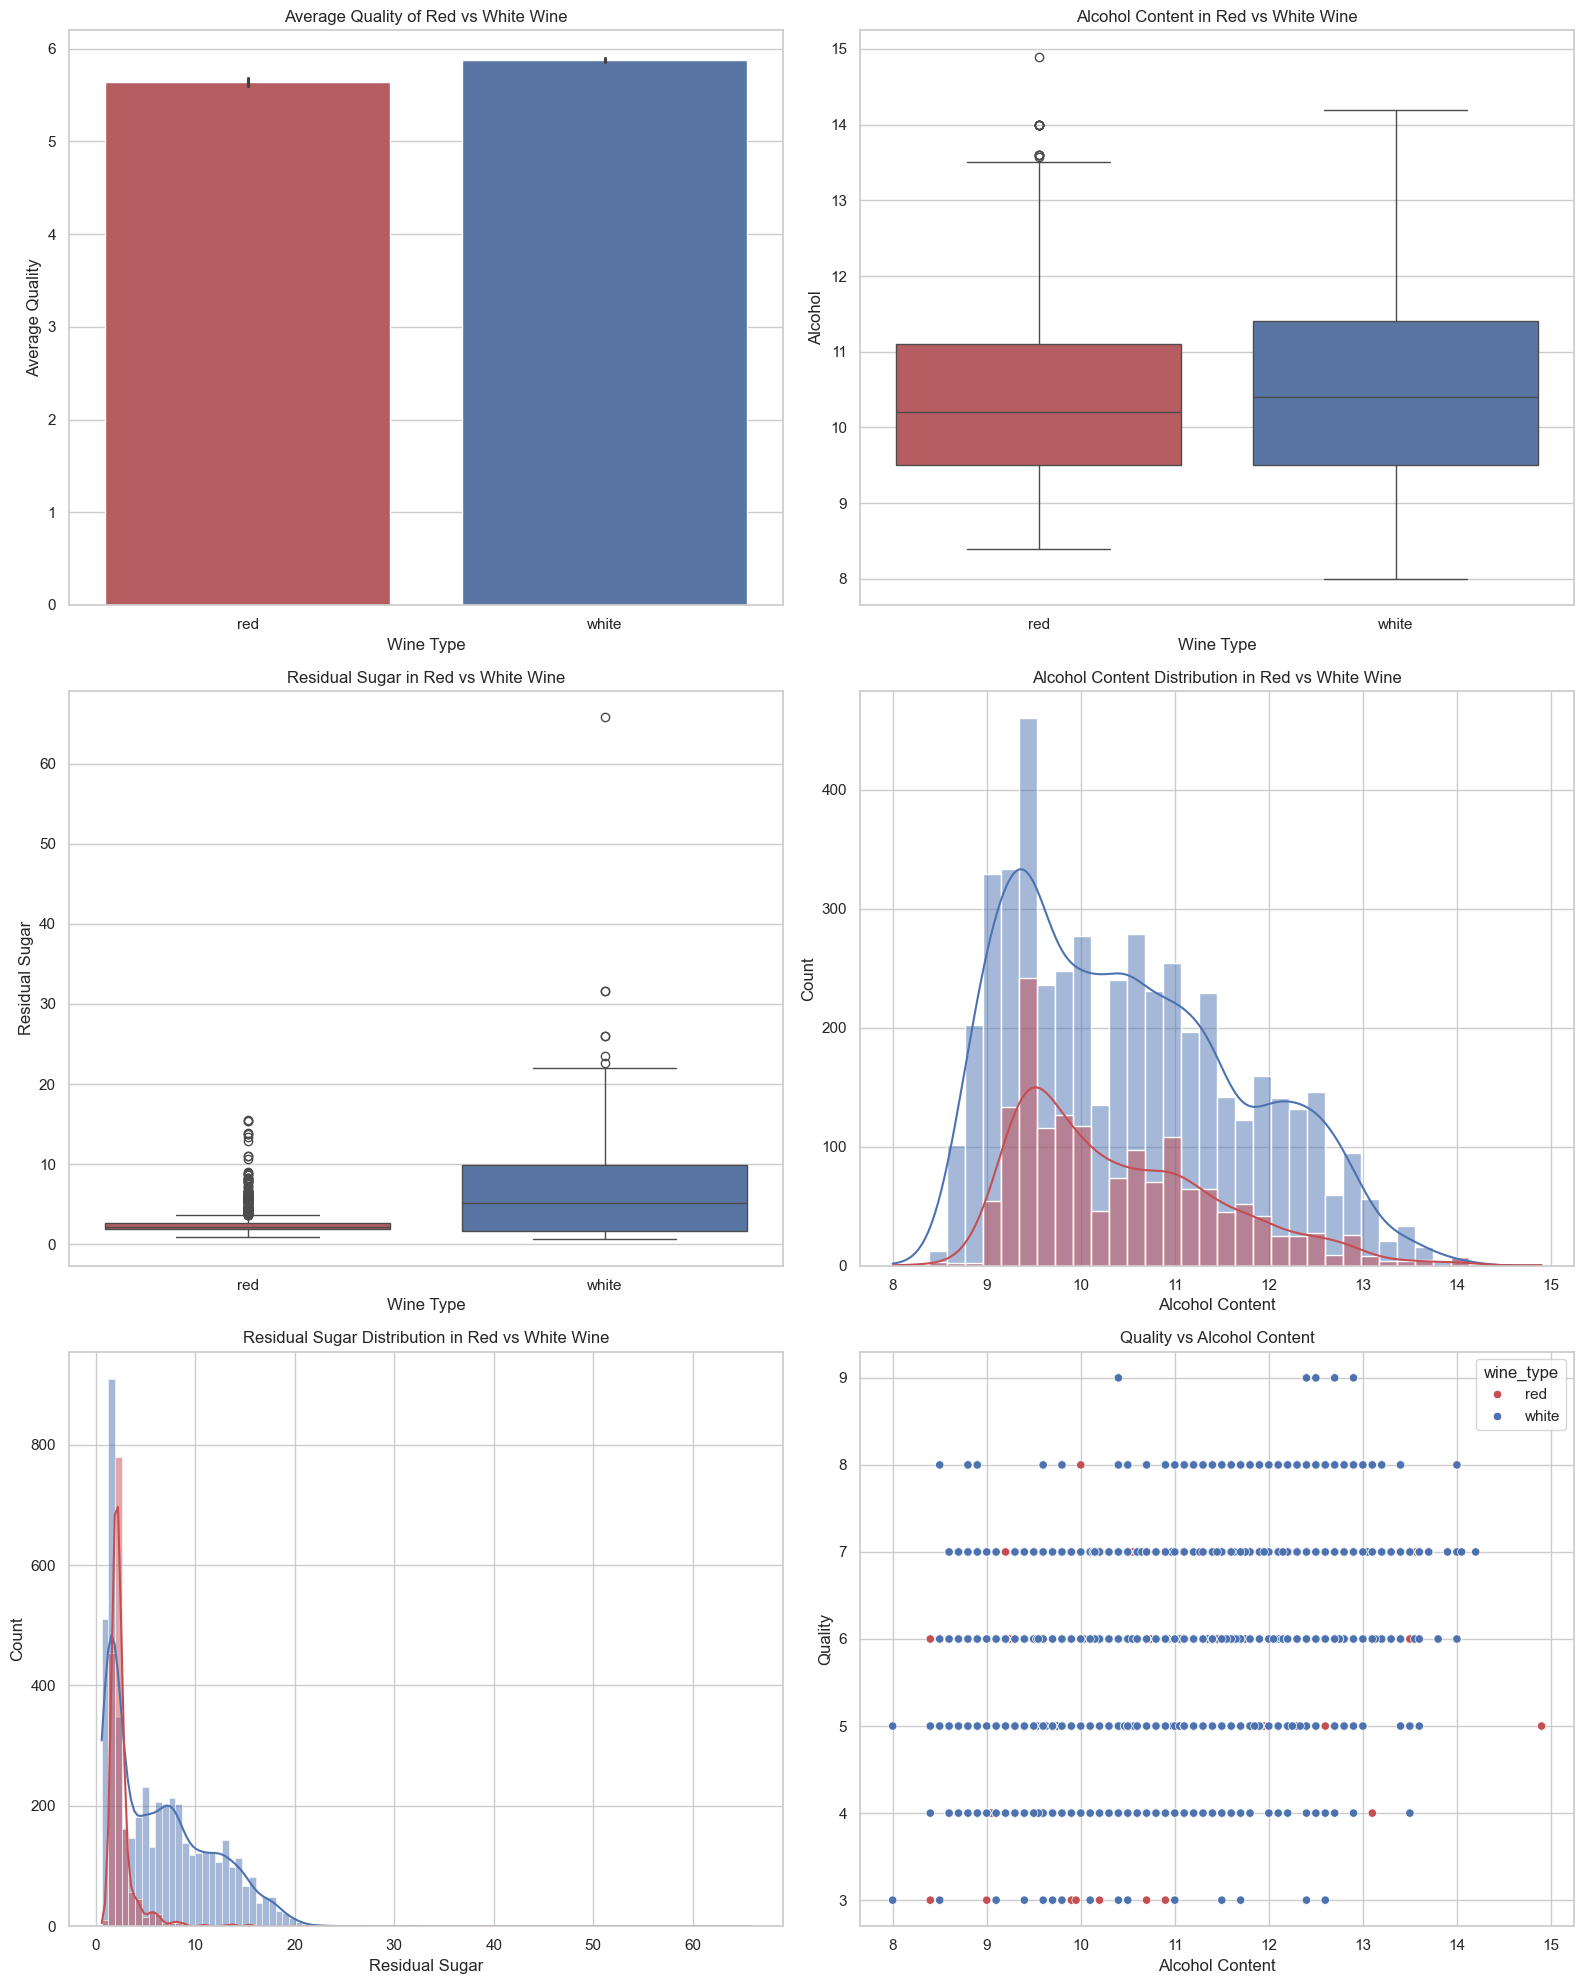

In [235]:
# Renaming columns for clarity
combined_wine_df.columns = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "density",
    "pH", "sulphates", "alcohol", "quality", "wine_type", "wine_type_encoded"
]

# Set figure size for visualizations
plt.figure(figsize=(16, 20))

# 1. Plotting the average quality of red vs white wine
plt.subplot(3, 2, 1)
sns.barplot(
    data=combined_wine_df,
    x="wine_type",
    y="quality",
    hue="wine_type",
    palette=["#C44E52", "#4C72B0"],
    legend=False
)
plt.title("Average Quality of Red vs White Wine")
plt.ylabel("Average Quality")
plt.xlabel("Wine Type")

# 2. Boxplot for alcohol content
plt.subplot(3, 2, 2)
sns.boxplot(
    data=combined_wine_df,
    x="wine_type",
    y="alcohol",
    hue="wine_type",
    palette=["#C44E52", "#4C72B0"],
    legend=False
)
plt.title("Alcohol Content in Red vs White Wine")
plt.ylabel("Alcohol")
plt.xlabel("Wine Type")

# 3. Boxplot for residual sugar content
plt.subplot(3, 2, 3)
sns.boxplot(
    data=combined_wine_df,
    x="wine_type",
    y="residual_sugar",
    hue="wine_type",
    palette=["#C44E52", "#4C72B0"],
    legend=False
)
plt.title("Residual Sugar in Red vs White Wine")
plt.ylabel("Residual Sugar")
plt.xlabel("Wine Type")

# 4. Histogram of alcohol content
plt.subplot(3, 2, 4)
sns.histplot(
    data=combined_wine_df,
    x="alcohol",
    hue="wine_type",
    kde=True,
    palette=["#C44E52", "#4C72B0"],
    legend=False
)
plt.title("Alcohol Content Distribution in Red vs White Wine")
plt.xlabel("Alcohol Content")

# 5. Histogram of residual sugar content
plt.subplot(3, 2, 5)
sns.histplot(
    data=combined_wine_df,
    x="residual_sugar",
    hue="wine_type",
    kde=True,
    palette=["#C44E52", "#4C72B0"],
    legend=False
)
plt.title("Residual Sugar Distribution in Red vs White Wine")
plt.xlabel("Residual Sugar")

# 6. Quality vs Alcohol content scatterplot
plt.subplot(3, 2, 6)
sns.scatterplot(
    data=combined_wine_df,
    x="alcohol",
    y="quality",
    hue="wine_type",
    palette=["#C44E52", "#4C72B0"]
)
plt.title("Quality vs Alcohol Content")
plt.xlabel("Alcohol Content")
plt.ylabel("Quality")

plt.tight_layout()
plt.show()

In [236]:

# Split the data into 5 bins based on 'pH'
bins_5 = pd.cut(combined_wine_df['pH'], bins=5)
density_5 = bins_5.value_counts()

# Split the data into 10 bins based on 'pH'
bins_10 = pd.cut(combined_wine_df['pH'], bins=10)
density_10 = bins_10.value_counts()

# Display the densities for the 5 bins
print("Density of 5 bins:")
print(density_5)

# Find the bin with the highest density for 5 bins
max_density_bin_5 = density_5.idxmax()
max_density_value_5 = density_5.max()
print(f"Bin with highest density (5 bins): {max_density_bin_5}, Density: {max_density_value_5}")

# Display the densities for the 10 bins
print("\nDensity of 10 bins:")
print(density_10)

# Find the bin with the highest density for 10 bins
max_density_bin_10 = density_10.idxmax()
max_density_value_10 = density_10.max()
print(f"Bin with highest density (10 bins): {max_density_bin_10}, Density: {max_density_value_10}")


Density of 5 bins:
pH
(2.978, 3.236]    3344
(3.236, 3.494]    2465
(2.719, 2.978]     350
(3.494, 3.752]     322
(3.752, 4.01]       16
Name: count, dtype: int64
Bin with highest density (5 bins): (2.978, 3.236], Density: 3344

Density of 10 bins:
pH
(3.107, 3.236]    2111
(3.236, 3.365]    1663
(2.978, 3.107]    1233
(3.365, 3.494]     802
(2.849, 2.978]     334
(3.494, 3.623]     263
(3.623, 3.752]      59
(2.719, 2.849]      16
(3.752, 3.881]      12
(3.881, 4.01]        4
Name: count, dtype: int64
Bin with highest density (10 bins): (3.107, 3.236], Density: 2111


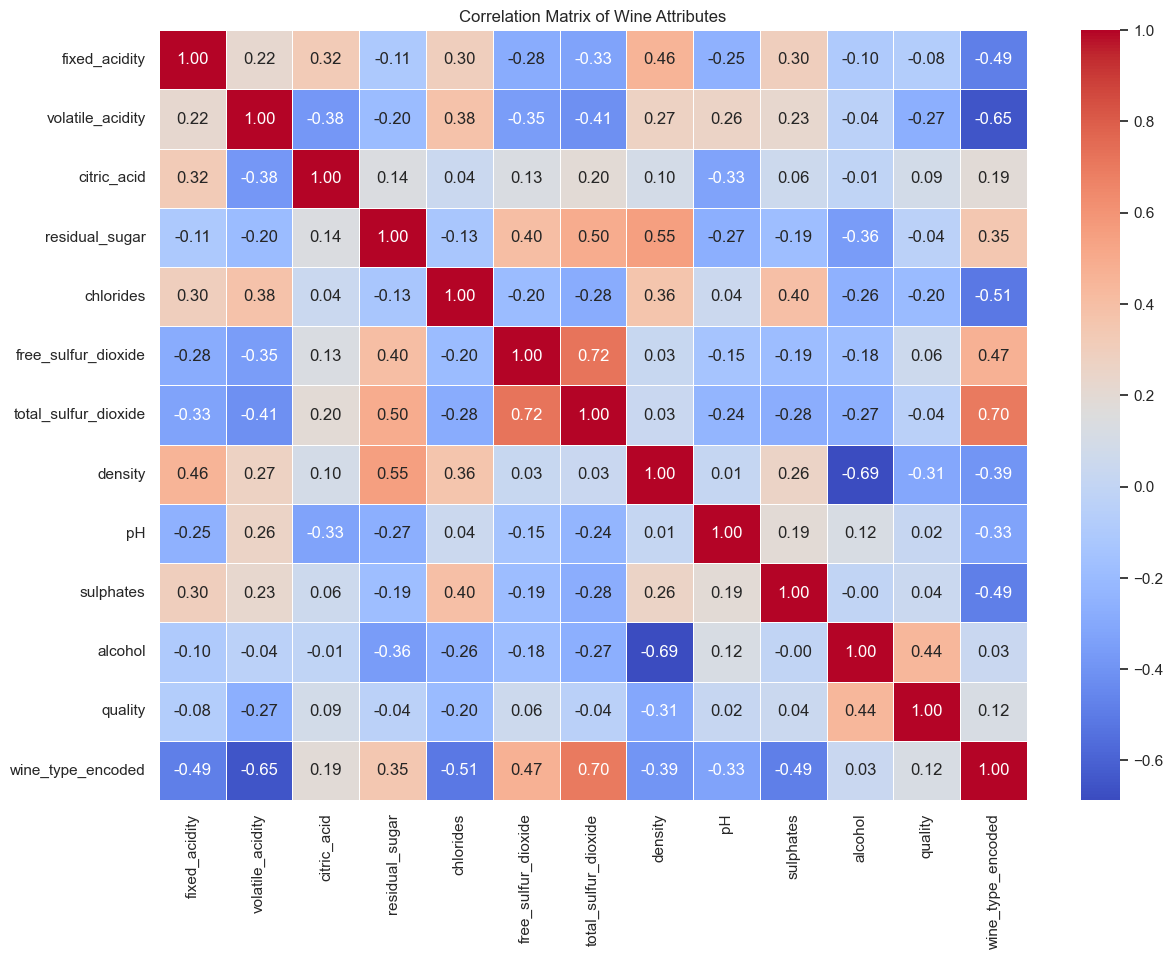

Attribute most strongly correlated with quality: quality (1.0)
Attribute least correlated with quality: density (-0.30585790606942276)

Highly correlated attributes (absolute correlation > 0.7):
                      fixed_acidity  volatile_acidity  citric_acid  \
fixed_acidity                   NaN               NaN          NaN   
volatile_acidity                NaN               NaN          NaN   
citric_acid                     NaN               NaN          NaN   
residual_sugar                  NaN               NaN          NaN   
chlorides                       NaN               NaN          NaN   
free_sulfur_dioxide             NaN               NaN          NaN   
total_sulfur_dioxide            NaN               NaN          NaN   
density                         NaN               NaN          NaN   
pH                              NaN               NaN          NaN   
sulphates                       NaN               NaN          NaN   
alcohol                         NaN

In [265]:
   # Select only numeric columns
numeric_columns = combined_wine_df.select_dtypes(include=[np.number])

# Calculate the correlation matrix using only numeric columns
correlation_matrix = numeric_columns.corr()

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Display the correlation matrix
plt.title("Correlation Matrix of Wine Attributes")
plt.show()

# Investigating correlations with 'quality'
correlation_with_quality = correlation_matrix['quality']

# Identify the attributes with highest and lowest correlation with quality
highest_corr = correlation_with_quality.idxmax()
highest_corr_value = correlation_with_quality.max()
lowest_corr = correlation_with_quality.idxmin()
lowest_corr_value = correlation_with_quality.min()

# Print results
print(f"Attribute most strongly correlated with quality: {highest_corr} ({highest_corr_value})")
print(f"Attribute least correlated with quality: {lowest_corr} ({lowest_corr_value})")

# Investigate other highly correlated attributes apart from 'quality'
highly_correlated = correlation_matrix[(correlation_matrix.abs() > 0.7) & (correlation_matrix != 1)]
print("\nHighly correlated attributes (absolute correlation > 0.7):")
print(highly_correlated)


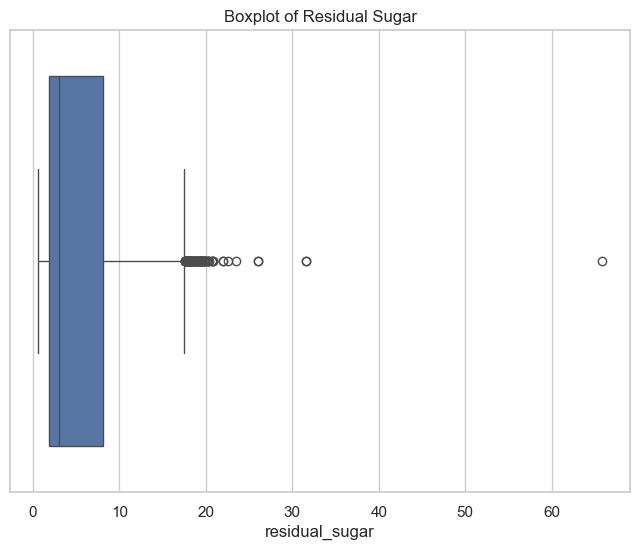

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
1599            7.0             0.270         0.36           20.70      0.045   
1606            7.0             0.270         0.36           20.70      0.045   
1613            8.3             0.420         0.62           19.25      0.040   
1637            7.3             0.240         0.39           17.95      0.057   
1638            7.3             0.240         0.39           17.95      0.057   
...             ...               ...          ...             ...        ...   
6290            6.9             0.190         0.31           19.25      0.043   
6293            6.9             0.190         0.31           19.25      0.043   
6347            6.1             0.340         0.24           18.35      0.050   
6348            6.2             0.350         0.25           18.40      0.051   
6377            5.8             0.315         0.19           19.40      0.031   

      free_sulfur_dioxide  

In [238]:
# Visualizing residual sugar with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=combined_wine_df, x='residual_sugar')
plt.title('Boxplot of Residual Sugar')
plt.show()

# Calculate the IQR for residual sugar
Q1 = combined_wine_df['residual_sugar'].quantile(0.25)
Q3 = combined_wine_df['residual_sugar'].quantile(0.75)
IQR = Q3 - Q1

# Identifying outliers
outliers = combined_wine_df[(combined_wine_df['residual_sugar'] < (Q1 - 1.5 * IQR)) | 
                             (combined_wine_df['residual_sugar'] > (Q3 + 1.5 * IQR))]

# Show the rows with outliers
print(outliers)

# Remove the outliers
combined_wine_df_cleaned = combined_wine_df[~combined_wine_df.index.isin(outliers.index)]

# Check the shape of the dataframe after removing outliers
print(f"Original dataframe shape: {combined_wine_df.shape}")
print(f"Shape after removing outliers: {combined_wine_df_cleaned.shape}")

In [239]:
# Select only numeric columns for correlation calculation
numeric_cols = combined_wine_df_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix using only numeric columns
correlation_matrix = combined_wine_df_cleaned[numeric_cols].corr()

# Display the correlation matrix
correlation_matrix

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,wine_type_encoded
fixed_acidity,1.000000,0.218109,0.325563,-0.111922,0.299625,-0.284629,-0.332462,0.488442,-0.256016,0.299558,-0.101879,-0.078600,-0.487295
volatile_acidity,0.218109,1.000000,-0.387041,-0.206351,0.378629,-0.352153,-0.416292,0.288780,0.261213,0.223359,-0.047745,-0.270659,-0.654622
citric_acid,0.325563,-0.387041,1.000000,0.136312,0.041898,0.129378,0.190704,0.087476,-0.332924,0.058384,-0.009271,0.091200,0.186979
residual_sugar,-0.111922,-0.206351,0.136312,1.000000,-0.135296,0.417426,0.500079,0.498042,-0.264136,-0.185939,-0.346413,-0.017497,0.351807
chlorides,0.299625,0.378629,0.041898,-0.135296,1.000000,-0.195653,-0.281232,0.385134,0.042837,0.396575,-0.263015,-0.202247,-0.513581
free_sulfur_dioxide,-0.284629,-0.352153,0.129378,0.417426,-0.195653,1.000000,0.720185,0.008990,-0.142162,-0.187180,-0.171165,0.062211,0.471326
total_sulfur_dioxide,-0.332462,-0.416292,0.190704,0.500079,-0.281232,0.720185,1.000000,0.000765,-0.231348,-0.277489,-0.253503,-0.034168,0.701093
density,0.488442,0.288780,0.087476,0.498042,0.385134,0.008990,0.000765,1.000000,0.030538,0.283635,-0.696973,-0.309706,-0.432292
pH,-0.256016,0.261213,-0.332924,-0.264136,0.042837,-0.142162,-0.231348,0.030538,1.000000,0.192850,0.111879,0.016654,-0.327005
sulphates,0.299558,0.223359,0.058384,-0.185939,0.396575,-0.187180,-0.277489,0.283635,0.192850,1.000000,-0.008732,0.037104,-0.486975


In [240]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select only numeric columns for PCA
numeric_cols = combined_wine_df_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined_wine_df_cleaned[numeric_cols])

# Apply PCA to reduce dimensions
pca = PCA(n_components=2)  # You can change this value depending on how many components you want to keep
principal_components = pca.fit_transform(scaled_data)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# If you want to see the amount of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

# Print the explained variance
print("Explained Variance Ratio for each principal component:", explained_variance)

# Optionally, you can merge the principal components back with the original dataset
combined_wine_df_cleaned_pca = pd.concat([combined_wine_df_cleaned, pca_df], axis=1)

# Display the first few rows of the transformed dataset
combined_wine_df_cleaned_pca.head()

Explained Variance Ratio for each principal component: [0.2980235  0.20241235]


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,wine_type,wine_type_encoded,PC1,PC2
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red,0.0,-3.841267,-0.047474
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0,red,0.0,-3.804060,0.592596
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0,red,0.0,-3.771919,0.350252
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0,red,0.0,-2.527318,1.354776
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red,0.0,-3.841267,-0.047474


In [257]:
# Print ten random rows from the PCA-transformed dataset
random_rows = combined_wine_df_cleaned_pca.sample(n=10, random_state=42)
random_rows.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,wine_type,wine_type_encoded,PC1,PC2
3139,7.1,0.18,0.74,15.6,0.044,44.0,176.0,0.99960,3.38,0.67,9.0,6.0,white,1.0,-0.920005,0.206359
1419,7.7,0.64,0.21,2.2,0.077,32.0,133.0,0.99560,3.27,0.45,9.9,5.0,red,0.0,-1.907246,0.566447
4835,6.9,0.22,0.39,6.0,0.035,44.0,141.0,0.99123,3.11,0.33,12.5,6.0,white,1.0,1.565314,-1.613116
4764,6.1,0.68,0.52,1.4,0.037,32.0,123.0,0.99022,3.24,0.45,12.0,6.0,white,1.0,1.154675,-2.382279
4094,6.3,0.18,0.22,1.5,0.043,45.0,155.0,0.99238,3.19,0.48,10.2,5.0,white,1.0,0.627695,-1.612005
